In [1]:
import pandas as pd
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
data =data = pd.read_csv(r"C:\Users\yuossef\Desktop\holistic\data\Housing.csv")

In [3]:
data = data.dropna()

In [4]:
data = data.drop_duplicates()

In [5]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

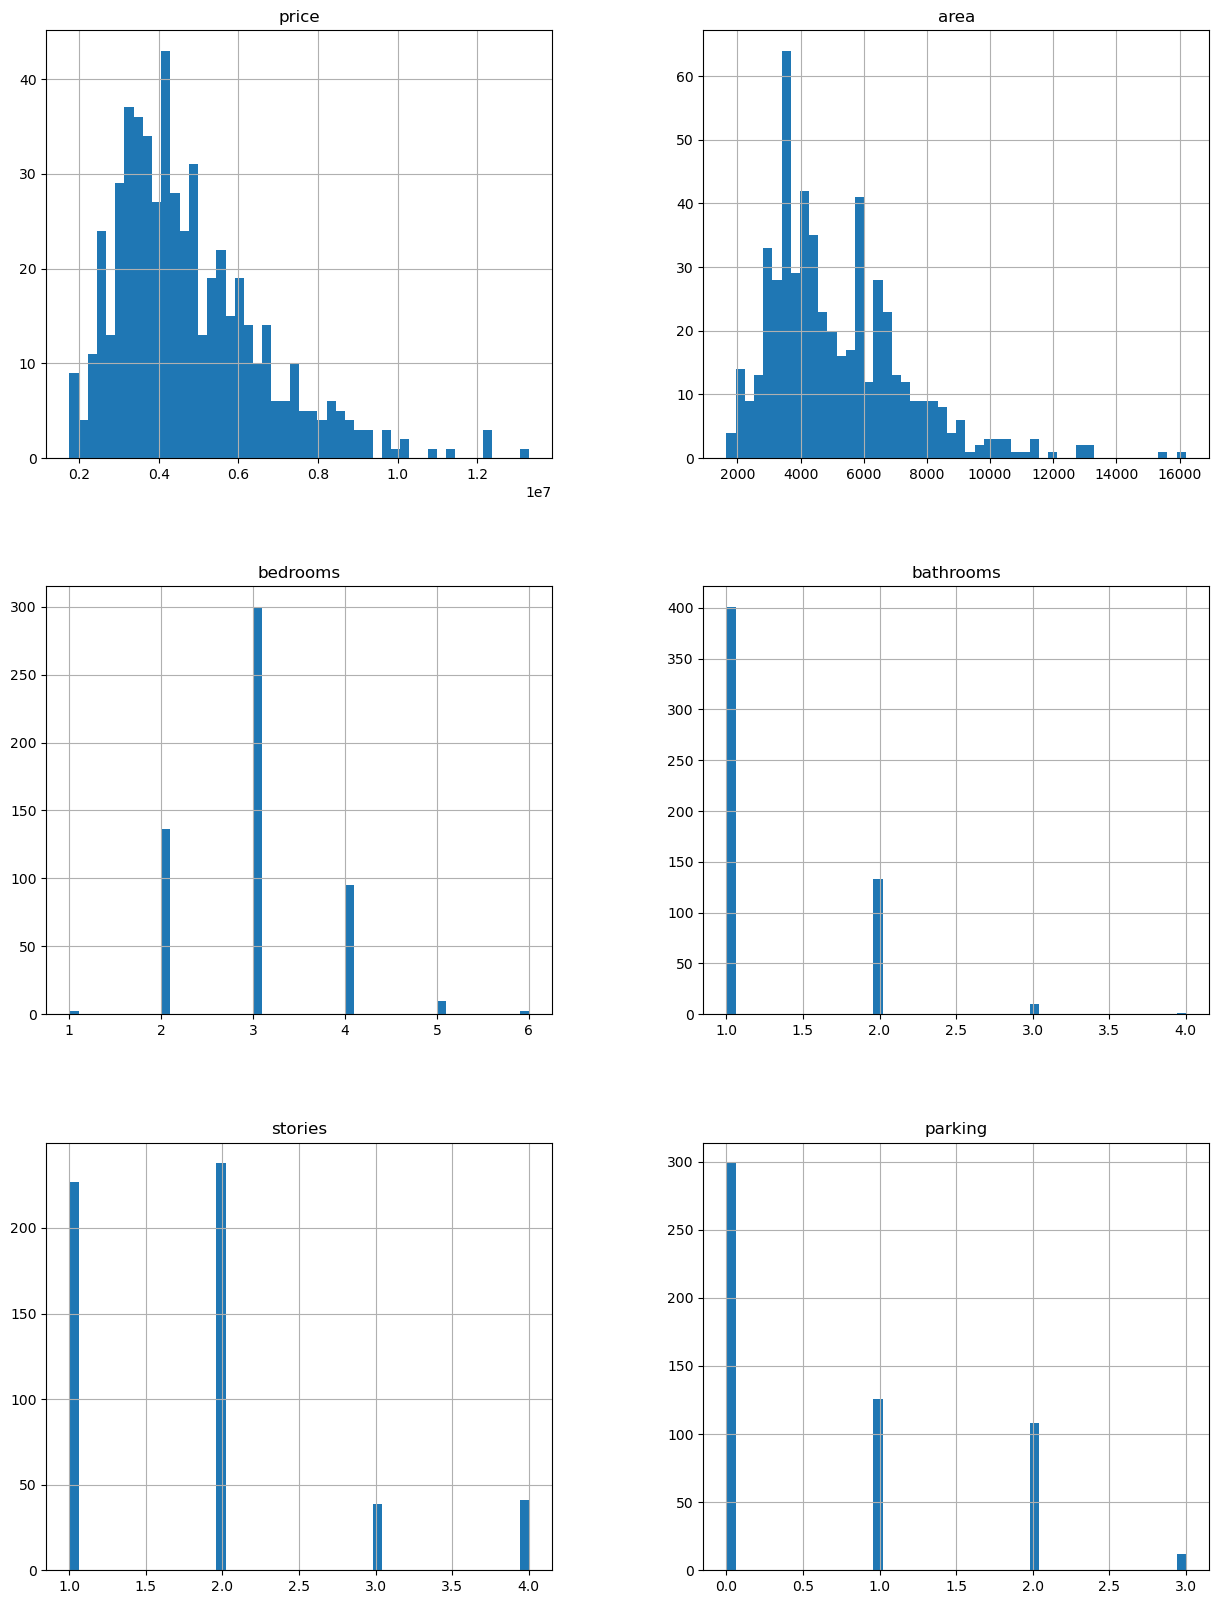

In [6]:
data.hist(bins=50, figsize=(15,20))

In [8]:
column_name = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
for i in column_name:
    le = LabelEncoder()
    data[i] = le.fit_transform(data[i])

In [9]:
data = pd.get_dummies(data, columns = ["furnishingstatus"])


In [10]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [11]:
x = data.drop("price", axis=1)
y = data["price"]

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state= 42)


In [13]:
model = LinearRegression()


In [14]:
model.fit(x_train, y_train)


LinearRegression()

In [15]:
y_pred = model.predict(x_test)

In [16]:
mean_squared_error(y_pred, y_test)


1754318687330.6628